# Task 1.2 - Modeling and Tuning Under Time Constraints (notebook-first)

This notebook is the development sandbox for all of Phase A of the plan. Once metrics on `data/validation/` clear `recall_ai >= 0.8` and `fpr_real <= 0.20`, the recipe ports to `_lib/` and the submission scripts.

Scope inside this notebook:
- A.1 Stratified 90/10 train/holdout split (Task 1.2 concern - not in `clean.py`)
- A.2/A.3 Streaming load of all five splits + per-channel norm stats on the fit fold
- A.4 Metrics block (recall_ai, fpr_real, precision_ai, accuracy, f1_ai, roc_auc, confusion, per-source-class recall)
- A.5 Threshold calibration with a 0.18 safety margin
- A.6 LR baseline on 33-dim engineered features (C grid)
- A.7 CNN with BatchNorm, class-balanced cross-entropy, AdamW, normalized inputs
- A.8 Ablation grid (optimizer, lr, class weight, batch)
- A.9 Final eval on validation + validation_augmented (touched exactly once)
- A.10 Failure-mode diagnostics (worst FPs / FNs)
- A.11 Budget proof + A.12 exit criteria

The Task 1.1 manifest at `artifacts/clean/train_manifest.csv` is the only thing read from disk that is older than this notebook.

In [70]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys, io as stdio, time, json, subprocess
from pathlib import Path

ROOT = Path.cwd().parent
SOLUTION = ROOT / "solution"
sys.path.insert(0, str(SOLUTION))

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score, roc_auc_score,
    confusion_matrix,
)

from _lib import seed, io as lio
from _lib.data import binarize_label

# seed.set_deterministic already calls torch.set_num_threads + set_num_interop_threads
# with a try/except guard. Calling those again would crash if torch parallel work
# has started in this process (e.g. on a re-run within the same kernel).
seed.set_deterministic(0)

DATA = SOLUTION / "data"
ARTIFACTS = SOLUTION / "artifacts"
NB_CACHE = ARTIFACTS / "notebook_cache"
CLEAN_DIR = ARTIFACTS / "clean"
NB_CACHE.mkdir(parents=True, exist_ok=True)

IMG_SIZE = lio.IMG_SIZE  # 224. Cleaning + memmap-cache resolution. Don't change.
CLASS_NAMES = {0: "real", 1: "SD2.1", 2: "SDXL", 3: "SD3", 4: "DALL-E3", 5: "Midjourney"}

# --- CPU training knobs -------------------------------------------------------
# Prior run on a laptop CPU: 1418s budget produced only ~0.6 epochs through the
# 26.7k fit set, recall_ai stalled at 0.54 (val) / 0.51 (val) for CNN + LR.
# Root cause: 224x224 forward/backward at k=32 = ~30 images/s. Two knobs cut
# this dramatically without violating any PDF constraint:
#
# (a) TRAIN_IMG_SIZE = 160 instead of 224 for the CNN forward/backward.
#     Cleaning still happens at 224 in clean.py so the aspect-ratio leak is
#     neutralised BEFORE this notebook runs - the leak fix is independent of
#     CNN resolution. Training at 96 is ~5x cheaper per step. PDF mandates no
#     specific resolution; CLAUDE.md style note "IMG_SIZE=224 everywhere" is
#     just convention, not a hard rule.
#
# (b) CNN_K = 16 halves conv channel counts. Forward/backward drops another
#     ~2x vs k=32. With <1 epoch reached at 224px/k=32, capacity loss does not
#     matter yet. Standard 3x3 conv (not DW-sep) is better for artifact detection.
#
# batch_to_chw / cnn_scores (cell with build_cnn_bn) downsample inside the
# data pipeline via F.interpolate. Memmap cache stays at 224 uint8 so LR
# feature extraction and worst-FP visualisation still see full-resolution
# images.
TRAIN_IMG_SIZE = 160
CNN_K = 16
# -----------------------------------------------------------------------------

assert (CLEAN_DIR / "train_manifest.csv").exists(), "run solution/clean.py first"
print("ready. data:", DATA.exists(), " cache:", NB_CACHE)
print(f"train_img_size={TRAIN_IMG_SIZE}  cnn_k={CNN_K}")

ready. data: True  cache: c:\Users\Agando\Documents\Projects\AI-Image-Detection-AMLS-Project\solution\artifacts\notebook_cache
train_img_size=160  cnn_k=16


## A.0 - Reference timing budget

`train_time_reference.py` is the Appendix-C synthetic CNN timing. We cache its elapsed seconds so this cell is instant on re-run. Budget for final CNN training = 5x the elapsed.

In [71]:
budget_cache = NB_CACHE / "budget.json"
if budget_cache.exists():
    info = json.loads(budget_cache.read_text())
    elapsed = float(info["reference_elapsed_s"])
    print(f"cached reference: {elapsed:.1f}s (delete {budget_cache} to re-run)")
else:
    ref = subprocess.run(
        [sys.executable, str(ROOT / "train_time_reference.py")],
        capture_output=True, text=True, check=True,
    )
    line = next(l for l in ref.stdout.splitlines() if "elapsed_seconds" in l)
    elapsed = float(line.split("=")[-1])
    budget_cache.write_text(json.dumps({"reference_elapsed_s": elapsed}))
    print(ref.stdout.strip())

BUDGET_S = 5.0 * elapsed
print(f"reference = {elapsed:.1f}s   training budget (5x) = {BUDGET_S:.1f}s")

cached reference: 155.6s (delete c:\Users\Agando\Documents\Projects\AI-Image-Detection-AMLS-Project\solution\artifacts\notebook_cache\budget.json to re-run)
reference = 155.6s   training budget (5x) = 778.1s


## A.1 - Stratified train/holdout split

Read the 5-col manifest from Task 1.1, filter validity, split 90/10 by `source_class` with seed 0. Persist `fold_assignment.csv` so `prepare.py` later reuses exactly the same partition.

In [72]:
HOLDOUT_FRAC = 0.10
SPLIT_SEED = 0

manifest = pd.read_csv(CLEAN_DIR / "train_manifest.csv")
manifest = manifest[manifest["is_valid"] == 1].reset_index(drop=True)

rng = np.random.default_rng(SPLIT_SEED)
fold_col = np.empty(len(manifest), dtype=object)
for cls in sorted(manifest["source_class"].unique()):
    idx_cls = manifest.index[manifest["source_class"] == cls].to_numpy()
    perm = rng.permutation(len(idx_cls))
    n_hold = int(round(len(idx_cls) * HOLDOUT_FRAC))
    hold_positions = set(perm[:n_hold].tolist())
    for pos, gi in enumerate(idx_cls):
        fold_col[gi] = "holdout" if pos in hold_positions else "fit"
manifest["fold"] = fold_col

fold_path = NB_CACHE / "fold_assignment.csv"
manifest[["parquet_file", "row_idx", "source_class", "fold"]].to_csv(fold_path, index=False)
print(f"fold -> {fold_path}")

print("\nfold counts per source_class:")
print(manifest.groupby(["source_class", "fold"]).size().unstack(fill_value=0))
print(f"\ntotal fit={int((manifest['fold']=='fit').sum())}, holdout={int((manifest['fold']=='holdout').sum())}")

def rows_for_fold(fold_name):
    sub = manifest[manifest["fold"] == fold_name]
    out = {}
    for f in sub["parquet_file"].unique():
        out[f] = set(sub.loc[sub["parquet_file"] == f, "row_idx"].tolist())
    return out

FIT_ROWS = rows_for_fold("fit")
HOLDOUT_ROWS = rows_for_fold("holdout")

fold -> c:\Users\Agando\Documents\Projects\AI-Image-Detection-AMLS-Project\solution\artifacts\notebook_cache\fold_assignment.csv

fold counts per source_class:
fold           fit  holdout
source_class               
0             4453      495
1             4453      495
2             4453      495
3             4453      495
4             4453      495
5             4453      495

total fit=26718, holdout=2970


## A.2 + A.3 - Load all splits as uint8 memmaps + compute norm stats

`train/` at full size is too big for RAM (~16 GB float32). Cache each split as a uint8 memmap under `artifacts/notebook_cache/` and normalize per batch. Per-channel mean/std are computed on the fit fold and persisted to `train_norm.json`.

Idempotent: rerun this cell and it loads instantly from disk.

In [73]:
def _decode_to_uint8(buf):
    arr = lio.clean_image(buf)
    if arr is None:
        return None
    return (arr * 255.0 + 0.5).astype(np.uint8)


def _build_cache(name, split_dir, row_filter=None):
    img_path = NB_CACHE / f"{name}_x.uint8.mmap"
    meta_path = NB_CACHE / f"{name}_meta.npz"
    if img_path.exists() and meta_path.exists():
        meta = np.load(meta_path)
        n = int(meta["n"])
        X = np.memmap(img_path, mode="r", dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE, 3))
        return X, meta["y"], meta["src"]

    files = sorted(split_dir.glob("*.parquet"))
    if row_filter is None:
        n_total = sum(pq.read_metadata(p).num_rows for p in files)
        keep = lambda f, i: True
    else:
        n_total = sum(len(s) for s in row_filter.values())
        keep = lambda f, i: i in row_filter.get(f, ())

    X = np.memmap(img_path, mode="w+", dtype=np.uint8, shape=(n_total, IMG_SIZE, IMG_SIZE, 3))
    y = np.zeros(n_total, dtype=np.int64)
    src = np.zeros(n_total, dtype=np.int64)

    write_idx = 0
    t0 = time.monotonic()
    for path in files:
        table = pq.read_table(path, columns=["image", "source_class"])
        imgs = table.column("image")
        labels = table.column("source_class")
        for i in range(len(table)):
            if not keep(path.name, i):
                continue
            arr = _decode_to_uint8(imgs[i].as_py())
            if arr is None:
                continue
            X[write_idx] = arr
            cls = int(labels[i].as_py())
            src[write_idx] = cls
            y[write_idx] = binarize_label(cls)
            write_idx += 1
    X.flush()
    print(f"  {name}: {write_idx} rows in {time.monotonic()-t0:.1f}s")
    np.savez(meta_path, n=write_idx, y=y[:write_idx], src=src[:write_idx])
    X = np.memmap(img_path, mode="r", dtype=np.uint8, shape=(write_idx, IMG_SIZE, IMG_SIZE, 3))
    return X, y[:write_idx], src[:write_idx]


print("loading splits (decode once, then cached)...")
X_fit,  y_fit,  src_fit  = _build_cache("train_fit",            DATA / "train",                 FIT_ROWS)
X_hold, y_hold, src_hold = _build_cache("train_holdout",        DATA / "train",                 HOLDOUT_ROWS)
X_cal,  y_cal,  src_cal  = _build_cache("calibration",          DATA / "calibration")
X_val,  y_val,  src_val  = _build_cache("validation",           DATA / "validation")
X_va,   y_va,   src_va   = _build_cache("validation_augmented", DATA / "validation_augmented")

for name, X, y in [("fit", X_fit, y_fit), ("holdout", X_hold, y_hold),
                   ("cal", X_cal, y_cal), ("val", X_val, y_val), ("val_aug", X_va, y_va)]:
    print(f"  {name:10s} n={len(X):5d}  ai_share={y.mean():.2%}")

loading splits (decode once, then cached)...
  fit        n=26718  ai_share=83.33%
  holdout    n= 2970  ai_share=83.33%
  cal        n= 1924  ai_share=83.26%
  val        n= 1124  ai_share=83.27%
  val_aug    n= 1124  ai_share=83.36%


In [74]:
norm_path = NB_CACHE / "train_norm.json"
if norm_path.exists():
    n = json.loads(norm_path.read_text())
    MEAN = np.asarray(n["mean"], dtype=np.float32)
    STD  = np.asarray(n["std"], dtype=np.float32)
    print(f"cached norm: mean={MEAN.round(4).tolist()}, std={STD.round(4).tolist()}")
else:
    sums   = np.zeros(3, dtype=np.float64)
    sumsqs = np.zeros(3, dtype=np.float64)
    n_pix  = 0
    CHUNK  = 256
    for i in range(0, len(X_fit), CHUNK):
        block = X_fit[i:i+CHUNK].astype(np.float32) / 255.0
        sums   += block.sum(axis=(0, 1, 2))
        sumsqs += (block * block).sum(axis=(0, 1, 2))
        n_pix  += block.shape[0] * block.shape[1] * block.shape[2]
    MEAN = (sums / n_pix).astype(np.float32)
    var  = np.maximum(sumsqs / n_pix - (sums / n_pix) ** 2, 0.0)
    STD  = np.sqrt(var).astype(np.float32)
    norm_path.write_text(json.dumps({
        "mean": MEAN.tolist(), "std": STD.tolist(),
        "n_images": int(len(X_fit)), "n_pixels": int(n_pix),
        "img_size": int(IMG_SIZE),
    }, indent=2))
    print(f"norm -> {norm_path}")
    print(f"mean={MEAN.round(4).tolist()}, std={STD.round(4).tolist()}")

cached norm: mean=[0.4878000020980835, 0.46799999475479126, 0.42730000615119934], std=[0.2531999945640564, 0.2468000054359436, 0.2574000060558319]


## A.4 - Metrics block

Single dict per eval call: recall_ai, fpr_real, precision_ai, accuracy, f1_ai, roc_auc, confusion, per-source-class recall, threshold, target_fpr. Cross-checked against sklearn.

In [75]:
def metrics_block(y_true, scores, src, threshold, target_fpr=None):
    y_true = np.asarray(y_true); scores = np.asarray(scores); src = np.asarray(src)
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])

    out = {
        "threshold":    float(threshold),
        "target_fpr":   float(target_fpr) if target_fpr is not None else None,
        "recall_ai":    float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "fpr_real":     float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "precision_ai": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "f1_ai":        float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "roc_auc":      float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) > 1 else float("nan"),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "n":  int(len(y_true)),
    }
    per = {}
    for c in range(1, 6):
        mask = src == c
        per[c] = float((y_pred[mask] == 1).mean()) if mask.sum() else float("nan")
    out["per_source_class_recall"] = per
    return out


def print_metrics(tag, m):
    print(f"[{tag}]  recall_ai={m['recall_ai']:.3f}  fpr_real={m['fpr_real']:.3f}  "
          f"prec_ai={m['precision_ai']:.3f}  acc={m['accuracy']:.3f}  f1={m['f1_ai']:.3f}  "
          f"auc={m['roc_auc']:.3f}  thr={m['threshold']:.3f}  n={m['n']}")
    print(f"    confusion: tn={m['tn']} fp={m['fp']} fn={m['fn']} tp={m['tp']}")
    pcr = m["per_source_class_recall"]
    parts = "  ".join(f"{CLASS_NAMES[c]}:{pcr[c]:.2f}" for c in range(1, 6))
    print(f"    per-class recall (AI only): {parts}")


yt = np.array([0,0,0,1,1,1,1])
ys = np.array([0.1, 0.9, 0.2, 0.8, 0.7, 0.3, 0.95])
sc = np.array([0,0,0,2,3,4,5])
m_test = metrics_block(yt, ys, sc, threshold=0.5, target_fpr=0.20)
print_metrics("sanity", m_test)
assert abs(m_test["recall_ai"] - 0.75) < 1e-9

[sanity]  recall_ai=0.750  fpr_real=0.333  prec_ai=0.750  acc=0.714  f1=0.750  auc=0.750  thr=0.500  n=7
    confusion: tn=2 fp=1 fn=1 tp=3
    per-class recall (AI only): SD2.1:nan  SDXL:1.00  SD3:1.00  DALL-E3:0.00  Midjourney:1.00


## A.5 - Calibration with safety margin

Smallest threshold s.t. empirical fpr_real on calibration reals <= target_fpr. Default target 0.18 to absorb cal->val sampling drift (cal 0.20 -> val 0.23 in the prior iteration).

In [76]:
def pick_threshold_for_fpr(scores_real, target_fpr=0.18):
    """Smallest t s.t. (scores_real >= t).mean() <= target_fpr.

    Iterates unique candidate thresholds ascending so the returned t is
    the minimum threshold actually meeting the FPR constraint. The previous
    quantile-index approach overshot when many real scores clustered at the
    boundary (ties caused more FPs than floor(target*n)).
    """
    s = np.asarray(scores_real, dtype=float)
    n = len(s)
    if n == 0:
        return 0.5
    max_fp = int(np.floor(target_fpr * n))
    if max_fp >= n:
        return float(s.min())
    candidates = np.sort(np.unique(s))  # ascending: lower t -> more FPs
    for t in candidates:
        if int((s >= t).sum()) <= max_fp:
            return float(t)
    return float(candidates[-1]) + 1e-9


def write_threshold_json(path, threshold, target_fpr, model_name):
    Path(path).write_text(json.dumps({
        "threshold":  float(threshold),
        "target_fpr": float(target_fpr),
        "model":      model_name,
    }, indent=2))


def read_threshold_json(path):
    return float(json.loads(Path(path).read_text())["threshold"])


rng = np.random.default_rng(0)
test = rng.uniform(0, 1, size=1000)
t = pick_threshold_for_fpr(test, target_fpr=0.18)
emp = (test >= t).mean()
print(f"smoke: target=0.18  realised={emp:.3f}  thr={t:.3f}")
assert emp <= 0.18 + 1 / len(test)

smoke: target=0.18  realised=0.180  thr=0.824


## A.6 - Classical baseline: LR on engineered features

101-dim features (color stats + histogram + Laplacian/Sobel + FFT bands + patch stats + noise + skewness + chroma noise + JPEG block score). `StandardScaler -> LogisticRegression(class_weight='balanced')`. C selected by **holdout recall_ai at provisional threshold from holdout reals**.

In [77]:
def _gray(X_f):
    return 0.299 * X_f[..., 0] + 0.587 * X_f[..., 1] + 0.114 * X_f[..., 2]


def _lap_var(g):
    lap = (-4 * g[:, 1:-1, 1:-1]
           + g[:, :-2, 1:-1] + g[:, 2:, 1:-1]
           + g[:, 1:-1, :-2] + g[:, 1:-1, 2:])
    return lap.reshape(len(g), -1).var(axis=1)


def _sobel_std(g):
    gx = g[:, 1:-1, 2:] - g[:, 1:-1, :-2]
    gy = g[:, 2:, 1:-1] - g[:, :-2, 1:-1]
    mag = np.sqrt(gx * gx + gy * gy)
    return mag.reshape(len(g), -1).std(axis=1)


def _fft_hf_ratio(g, hf_cutoff=0.25):
    f = np.fft.fft2(g)
    p = np.abs(f) ** 2
    h, w = g.shape[1], g.shape[2]
    yy, xx = np.meshgrid(np.fft.fftfreq(h), np.fft.fftfreq(w), indexing="ij")
    r = np.sqrt(yy * yy + xx * xx)
    mask_hf = r > hf_cutoff
    total = p.reshape(len(g), -1).sum(axis=1) + 1e-9
    hf = (p * mask_hf).reshape(len(g), -1).sum(axis=1)
    return hf / total


def _fft_band_ratios(g, bands=((0.0, 0.05), (0.05, 0.15), (0.15, 0.30), (0.30, 0.50))):
    """Spectral power fraction in 4 frequency bands (DC to Nyquist)."""
    f = np.fft.fft2(g)
    p = np.abs(f) ** 2
    h, w = g.shape[1], g.shape[2]
    yy, xx = np.meshgrid(np.fft.fftfreq(h), np.fft.fftfreq(w), indexing="ij")
    r = np.sqrt(yy * yy + xx * xx)
    total = p.reshape(len(g), -1).sum(axis=1) + 1e-9
    out = []
    for lo, hi in bands:
        mask = (r >= lo) & (r < hi)
        out.append((p * mask).reshape(len(g), -1).sum(axis=1) / total)
    return np.stack(out, axis=1)  # (N, 4)


def _patch_stats(X, grid=3):
    # per-patch per-channel mean+std over a grid x grid spatial grid
    n, h, w, c = X.shape
    ph, pw = h // grid, w // grid
    out = []
    for ri in range(grid):
        for ci in range(grid):
            patch = X[:, ri*ph:(ri+1)*ph, ci*pw:(ci+1)*pw, :]
            out.append(patch.mean(axis=(1, 2)))
            out.append(patch.std(axis=(1, 2)))
    return np.concatenate(out, axis=1)  # (N, grid*grid*3*2)


def _noise_std(X):
    # 3x3 box-blur residual per-channel std -- real camera noise vs AI denoiser
    padded = np.pad(X, ((0,0),(1,1),(1,1),(0,0)), mode="edge")
    blur = (padded[:,:-2,:-2] + padded[:,:-2,1:-1] + padded[:,:-2,2:] +
            padded[:,1:-1,:-2] + padded[:,1:-1,1:-1] + padded[:,1:-1,2:] +
            padded[:,2:,:-2] + padded[:,2:,1:-1] + padded[:,2:,2:]) / 9.0
    noise = (X - blur).reshape(len(X), -1, 3)
    return noise.std(axis=1)  # (N, 3)


def _channel_skewness(X):
    """Per-channel skewness (3rd standardized moment). AI images tend toward symmetric distributions."""
    mu = X.mean(axis=(1, 2), keepdims=True)
    sigma = X.std(axis=(1, 2), keepdims=True) + 1e-8
    return (((X - mu) / sigma) ** 3).mean(axis=(1, 2))  # (N, 3)


def _chroma_noise(X):
    """Box-blur residual std in Cb and Cr channels. Real cameras have chromatic noise; AI models do not."""
    cb = -0.16874 * X[..., 0] - 0.33126 * X[..., 1] + 0.5     * X[..., 2]
    cr =  0.5     * X[..., 0] - 0.41869 * X[..., 1] - 0.08131 * X[..., 2]
    out = []
    for ch in (cb, cr):
        padded = np.pad(ch, ((0,0),(1,1),(1,1)), mode="edge")
        blur = (padded[:,:-2,:-2] + padded[:,:-2,1:-1] + padded[:,:-2,2:] +
                padded[:,1:-1,:-2] + padded[:,1:-1,1:-1] + padded[:,1:-1,2:] +
                padded[:,2:,:-2] + padded[:,2:,1:-1] + padded[:,2:,2:]) / 9.0
        out.append((ch - blur).reshape(len(X), -1).std(axis=1))
    return np.stack(out, axis=1)  # (N, 2)


def _jpeg_block_score(g):
    """Mean absolute discontinuity at 8-pixel JPEG DCT block boundaries."""
    n_h = (g.shape[2] // 8) - 1
    right_cols = np.arange(8, 8 + n_h * 8, 8)
    left_cols  = right_cols - 1
    h_diff = np.abs(g[:, :, right_cols] - g[:, :, left_cols]).mean(axis=(1, 2))

    n_v = (g.shape[1] // 8) - 1
    bottom_rows = np.arange(8, 8 + n_v * 8, 8)
    top_rows    = bottom_rows - 1
    v_diff = np.abs(g[:, bottom_rows, :] - g[:, top_rows, :]).mean(axis=(1, 2))

    return np.stack([h_diff, v_diff], axis=1)  # (N, 2)


def features_from_uint8(X_u8, chunk=256):
    # 101-dim: mean(3) + std(3) + hist(24) + lap(1) + sob(1) + hf(1) + bands(4)
    #          + patch(54) + noise(3) + skew(3) + chroma(2) + block(2)
    n = len(X_u8)
    F_out = np.zeros((n, 101), dtype=np.float32)
    for i in range(0, n, chunk):
        X = X_u8[i:i+chunk].astype(np.float32) / 255.0
        mean = X.mean(axis=(1, 2))
        std  = X.std(axis=(1, 2))
        hist = np.zeros((X.shape[0], 24), dtype=np.float32)
        for c in range(3):
            edges = np.linspace(0, 1, 9)
            for b in range(8):
                lo, hi = edges[b], edges[b + 1]
                hist[:, c * 8 + b] = ((X[..., c] >= lo) & (X[..., c] < hi)).mean(axis=(1, 2))
        g     = _gray(X)
        lap   = _lap_var(g)
        sob   = _sobel_std(g)
        hf    = _fft_hf_ratio(g)
        bands = _fft_band_ratios(g)
        patch = _patch_stats(X)
        noise = _noise_std(X)
        skew  = _channel_skewness(X)
        chroma = _chroma_noise(X)
        block  = _jpeg_block_score(g)
        F_out[i:i+chunk] = np.concatenate(
            [mean, std, hist, lap[:, None], sob[:, None], hf[:, None],
             bands, patch, noise, skew, chroma, block], axis=1
        )
    return F_out


def features_cached(name, X_u8):
    """Cache 101-dim engineered features to .npz so re-runs are instant."""
    cache = NB_CACHE / f"features_v3_{name}.npz"
    if cache.exists():
        return np.load(cache)["F"]
    F = features_from_uint8(X_u8)
    np.savez_compressed(cache, F=F)
    return F


print("extracting engineered features (cached after first run)...")
t0 = time.monotonic()
F_fit  = features_cached("fit",      X_fit)
F_hold = features_cached("holdout",  X_hold)
F_cal  = features_cached("cal",      X_cal)
F_val  = features_cached("val",      X_val)
F_va   = features_cached("val_aug",  X_va)
print(f"features ready in {time.monotonic()-t0:.1f}s. dim={F_fit.shape[1]}")

extracting engineered features (cached after first run)...
features ready in 0.1s. dim=101


In [78]:
# --- Fast feature extraction benchmark ---
# Tests 112px (2x downsampled + single FFT) vs original 224px.
# If RF AUC / holdout recall are comparable we use the fast version in scripts.

_FEAT_SIZE_FAST = 112
_SCALE_FAST     = 2    # 224 // 112
_JPEG_BS_FAST   = 4    # 8 // _SCALE_FAST

_fft_yy, _fft_xx = np.meshgrid(
    np.fft.fftfreq(_FEAT_SIZE_FAST), np.fft.fftfreq(_FEAT_SIZE_FAST), indexing="ij"
)
_fft_r      = np.sqrt(_fft_yy**2 + _fft_xx**2)
_hf_mask    = _fft_r > 0.25
_band_masks = [(_fft_r >= lo) & (_fft_r < hi)
               for lo, hi in ((0.0, 0.05), (0.05, 0.15), (0.15, 0.30), (0.30, 0.50))]


def _jpeg_block_score_bs(g, block_size):
    """_jpeg_block_score with parameterised block size (4 for 112px images)."""
    n_h = (g.shape[2] // block_size) - 1
    right_cols = np.arange(block_size, block_size + n_h * block_size, block_size)
    left_cols  = right_cols - 1
    h_diff = np.abs(g[:, :, right_cols] - g[:, :, left_cols]).mean(axis=(1, 2))
    n_v = (g.shape[1] // block_size) - 1
    bottom_rows = np.arange(block_size, block_size + n_v * block_size, block_size)
    top_rows    = bottom_rows - 1
    v_diff = np.abs(g[:, bottom_rows, :] - g[:, top_rows, :]).mean(axis=(1, 2))
    return np.stack([h_diff, v_diff], axis=1)


def features_from_uint8_fast(X_u8, chunk=256):
    """Same 101-dim features at 112px (2x2 box avg) with single FFT per chunk."""
    n = len(X_u8)
    F_out = np.zeros((n, 101), dtype=np.float32)
    for i in range(0, n, chunk):
        raw = X_u8[i:i+chunk]
        raw_f = raw.astype(np.float32)
        raw_f = raw_f.reshape(len(raw_f), _FEAT_SIZE_FAST, _SCALE_FAST,
                               _FEAT_SIZE_FAST, _SCALE_FAST, 3)
        X = (raw_f.mean(axis=(2, 4)) / 255.0).astype(np.float32)

        mean = X.mean(axis=(1, 2))
        std  = X.std(axis=(1, 2))
        hist = np.zeros((X.shape[0], 24), dtype=np.float32)
        edges = np.linspace(0, 1, 9)
        for c in range(3):
            for b in range(8):
                hist[:, c*8+b] = ((X[..., c] >= edges[b]) & (X[..., c] < edges[b+1])).mean(axis=(1, 2))

        g   = _gray(X)
        lap = _lap_var(g)
        sob = _sobel_std(g)

        fft_p   = np.abs(np.fft.fft2(g)) ** 2
        fft_tot = fft_p.reshape(len(g), -1).sum(axis=1) + 1e-9
        hf    = (fft_p * _hf_mask).reshape(len(g), -1).sum(axis=1) / fft_tot
        bands = np.stack([(fft_p * m).reshape(len(g), -1).sum(axis=1) / fft_tot
                          for m in _band_masks], axis=1)

        patch  = _patch_stats(X)
        noise  = _noise_std(X)
        skew   = _channel_skewness(X)
        chroma = _chroma_noise(X)
        block  = _jpeg_block_score_bs(g, _JPEG_BS_FAST)

        F_out[i:i+chunk] = np.concatenate(
            [mean, std, hist, lap[:, None], sob[:, None], hf[:, None],
             bands, patch, noise, skew, chroma, block], axis=1
        )
    return F_out


print("=== Fast feature benchmark ===")
t0 = time.monotonic()
F_fit_fast  = features_from_uint8_fast(X_fit)
F_hold_fast = features_from_uint8_fast(X_hold)
F_cal_fast  = features_from_uint8_fast(X_cal)
F_val_fast  = features_from_uint8_fast(X_val)
F_va_fast   = features_from_uint8_fast(X_va)
print(f"112px features: {time.monotonic()-t0:.1f}s  dim={F_fit_fast.shape[1]}")

from sklearn.ensemble import RandomForestClassifier as _RFC
from sklearn.metrics import roc_auc_score as _auc

print("\nRF n=400 comparison:")
for label, F_tr, F_ho in [("224px (original)", F_fit,      F_hold),
                           ("112px (fast)    ", F_fit_fast, F_hold_fast)]:
    _rf = _RFC(n_estimators=400, n_jobs=-1, random_state=0,
               class_weight="balanced", max_features="sqrt")
    _rf.fit(F_tr, y_fit)
    _p  = _rf.predict_proba(F_ho)[:, 1]
    _t  = pick_threshold_for_fpr(_p[y_hold == 0], target_fpr=0.18)
    _r  = float(((_p >= _t) & (y_hold == 1)).sum() / max(int((y_hold == 1).sum()), 1))
    _au = float(_auc(y_hold, _p))
    print(f"  {label}: holdout recall={_r:.3f}  AUC={_au:.4f}")


=== Fast feature benchmark ===
112px features: 186.9s  dim=101

RF n=400 comparison:
  224px (original): holdout recall=0.781  AUC=0.8852
  112px (fast)    : holdout recall=0.731  AUC=0.8610


In [79]:
_rf_t0 = time.monotonic()
best_lr = {"C": None, "recall": -1.0, "pipe": None}
for C in (0.1, 1.0, 10.0):
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("lr",    LogisticRegression(class_weight="balanced", max_iter=2000, C=C)),
    ])
    pipe.fit(F_fit, y_fit)
    p_hold = pipe.predict_proba(F_hold)[:, 1]
    thr = pick_threshold_for_fpr(p_hold[y_hold == 0], target_fpr=0.18)
    m = metrics_block(y_hold, p_hold, src_hold, threshold=thr, target_fpr=0.18)
    print_metrics(f"LR C={C:>5} (holdout)", m)
    if m["recall_ai"] > best_lr["recall"]:
        best_lr = {"C": C, "recall": m["recall_ai"], "pipe": pipe}

print(f"\n=== best LR C={best_lr['C']}, holdout recall_ai={best_lr['recall']:.3f} ===")
LR_PIPE = best_lr["pipe"]
# Random Forest -- non-linear, no scaling needed, fast with n_jobs=-1
from sklearn.ensemble import RandomForestClassifier

best_rf = {"n": None, "recall": -1.0, "pipe": None}
for n_est in (200, 400):
    rf = RandomForestClassifier(
        n_estimators=n_est, n_jobs=-1, random_state=0,
        class_weight="balanced", max_features="sqrt",
    )
    rf.fit(F_fit, y_fit)
    p_hold = rf.predict_proba(F_hold)[:, 1]
    thr = pick_threshold_for_fpr(p_hold[y_hold == 0], target_fpr=0.18)
    m = metrics_block(y_hold, p_hold, src_hold, threshold=thr, target_fpr=0.18)
    print_metrics(f"RF n={n_est:>4} (holdout)", m)
    if m["recall_ai"] > best_rf["recall"]:
        best_rf = {"n": n_est, "recall": m["recall_ai"], "pipe": rf}

print(f"=== best RF n={best_rf['n']}, holdout recall_ai={best_rf['recall']:.3f} ===")

# pick best classical model overall
if best_rf["recall"] > best_lr["recall"]:
    print("classical winner: Random Forest")
    LR_PIPE = best_rf["pipe"]
else:
    print("classical winner: Logistic Regression")

rf_train_s = time.monotonic() - _rf_t0
print(f"RF/LR training: {rf_train_s:.1f}s")

[LR C=  0.1 (holdout)]  recall_ai=0.723  fpr_real=0.180  prec_ai=0.953  acc=0.739  f1=0.822  auc=0.846  thr=0.584  n=2970
    confusion: tn=406 fp=89 fn=686 tp=1789
    per-class recall (AI only): SD2.1:0.71  SDXL:0.89  SD3:0.58  DALL-E3:0.67  Midjourney:0.77
[LR C=  1.0 (holdout)]  recall_ai=0.731  fpr_real=0.180  prec_ai=0.953  acc=0.746  f1=0.828  auc=0.850  thr=0.592  n=2970
    confusion: tn=406 fp=89 fn=665 tp=1810
    per-class recall (AI only): SD2.1:0.71  SDXL:0.89  SD3:0.60  DALL-E3:0.68  Midjourney:0.78
[LR C= 10.0 (holdout)]  recall_ai=0.749  fpr_real=0.180  prec_ai=0.954  acc=0.761  f1=0.839  auc=0.857  thr=0.586  n=2970
    confusion: tn=406 fp=89 fn=622 tp=1853
    per-class recall (AI only): SD2.1:0.72  SDXL:0.90  SD3:0.60  DALL-E3:0.72  Midjourney:0.80

=== best LR C=10.0, holdout recall_ai=0.749 ===
[RF n= 200 (holdout)]  recall_ai=0.765  fpr_real=0.178  prec_ai=0.956  acc=0.775  f1=0.850  auc=0.881  thr=0.825  n=2970
    confusion: tn=407 fp=88 fn=581 tp=1894
    per

## A.7 - CNN with BN, class weights, AdamW

Appendix-B family + BatchNorm after each conv. `CrossEntropyLoss(weight=[w_real, w_ai])` where `w_c = N / (2 * n_c)` counters the 84/16 imbalance. AdamW lr=1e-4 wd=1e-4. Batch 64. Inputs normalized with MEAN/STD from A.3.

`train_cnn`: deadline loop, eval every 30 s on `train_holdout`, best-by-holdout-recall checkpoint, patience 5.

**Throughput tuning (see cell 1 for rationale):** CNN forward/backward runs at `TRAIN_IMG_SIZE=96` (memmap is still 224 uint8; `batch_to_chw` downsamples bilinear after normalization). Channel width `CNN_K=16` instead of 32. Together ~10x faster than 224/k=32 on a CPU laptop, letting the CNN reach 5-10 full epochs in the 5x reference budget instead of <1 epoch.

In [80]:
class FocalLoss(nn.Module):
    """Down-weights easy examples so training focuses on hard cases (SD3, SD2.1)."""
    def __init__(self, gamma=1.5, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets, sample_weight=None):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()


def build_cnn_bn(k=CNN_K, num_classes=2):
    """5-layer CNN with BatchNorm. Standard 3x3 conv preserves spatial+channel mixing
    needed to detect subtle per-pixel AI artifacts. k=16 leaves enough budget for
    ~700s of training."""
    def _block(in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
        )
    return nn.Sequential(
        _block(3,    k),   nn.MaxPool2d(2),
        _block(k,  2*k),   nn.MaxPool2d(2),
        _block(2*k, 4*k),
        _block(4*k, 8*k),
        _block(8*k, 8*k),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(8 * k, 4 * k), nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(4 * k, num_classes),
    )


def class_weights(y):
    counts = np.bincount(y, minlength=2).astype(np.float64)
    n = counts.sum()
    w = n / (2.0 * np.maximum(counts, 1))
    return torch.from_numpy(w.astype(np.float32))


def batch_to_chw(idx_chunk, X_u8, mean, std, target_size=TRAIN_IMG_SIZE):
    """uint8 memmap slice -> normalized CHW float tensor, optionally downsampled.

    Memmap is at IMG_SIZE=224. CNN trains at target_size=128 (see cell 1 rationale).
    Downsample via bilinear F.interpolate after normalization keeps gradients well
    behaved and matches the eval-time transform exactly.
    """
    block = X_u8[idx_chunk].astype(np.float32) / 255.0
    block = (block - mean) / std
    t = torch.from_numpy(block).permute(0, 3, 1, 2).contiguous()
    if target_size is not None and t.shape[-1] != target_size:
        t = F.interpolate(t, size=target_size, mode="bilinear", align_corners=False)
    return t


@torch.no_grad()
def cnn_scores(model, X_u8, mean, std, batch=128, target_size=TRAIN_IMG_SIZE):
    model.eval()
    out = []
    for i in range(0, len(X_u8), batch):
        idx = np.arange(i, min(i + batch, len(X_u8)))
        xt = batch_to_chw(idx, X_u8, mean, std, target_size=target_size)
        logits = model(xt)
        out.append(torch.softmax(logits, dim=1)[:, 1].numpy())
    return np.concatenate(out)


def train_cnn(
    model, X_fit, y_fit, X_hold, y_hold, src_hold,
    mean, std, deadline,
    optimizer_cls=torch.optim.AdamW, lr=1e-4, weight_decay=1e-4,
    batch=64, use_class_weight=True, eval_every_s=30.0, patience=8, verbose=True,
    target_size=TRAIN_IMG_SIZE,
    src_fit=None, sd3_weight=2.0,
):
    opt = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    w = class_weights(y_fit) if use_class_weight else None
    loss_fn = FocalLoss(gamma=1.5, weight=w)
    yt_fit = torch.from_numpy(y_fit).long()
    n = len(X_fit)
    history = []
    best = {"recall": -1.0, "state": None, "thr": 0.5, "metrics": None}
    last_eval = time.monotonic()
    no_improve = 0
    step = 0
    loss_window = []
    loss_window_size = 50

    sw_fit = None
    if src_fit is not None:
        _sw = torch.ones(n, dtype=torch.float32)
        _sw[np.asarray(src_fit) == 3] = sd3_weight
        sw_fit = _sw
    model.train()
    while time.monotonic() < deadline:
        perm = np.random.permutation(n)
        for i in range(0, n, batch):
            if time.monotonic() >= deadline:
                break
            ix = perm[i:i+batch]
            xt = batch_to_chw(ix, X_fit, mean, std, target_size=target_size)
            logits = model(xt)
            loss = loss_fn(logits, yt_fit[ix], sw_fit[ix] if sw_fit is not None else None)
            opt.zero_grad(); loss.backward(); opt.step()
            step += 1
            loss_window.append(float(loss.item()))
            if len(loss_window) > loss_window_size:
                loss_window.pop(0)

            if time.monotonic() - last_eval >= eval_every_s:
                scores = cnn_scores(model, X_hold, mean, std, target_size=target_size)
                thr = pick_threshold_for_fpr(scores[y_hold == 0], target_fpr=0.20)
                m = metrics_block(y_hold, scores, src_hold, threshold=thr, target_fpr=0.18)
                m["step"] = step
                m["t"] = time.monotonic()
                m["loss_ma"] = float(np.mean(loss_window))
                history.append(m)
                if verbose:
                    print_metrics(f"step={step} loss_ma={m['loss_ma']:.3f} holdout", m)
                if m["recall_ai"] > best["recall"] + 1e-4:
                    best = {
                        "recall":  m["recall_ai"],
                        "state":   {k: v.clone() for k, v in model.state_dict().items()},
                        "thr":     thr,
                        "metrics": m,
                    }
                    no_improve = 0
                else:
                    no_improve += 1
                model.train()
                last_eval = time.monotonic()
                if no_improve >= patience:
                    if verbose:
                        print(f"early stop: no improvement in {patience} evals")
                    return best, history
    return best, history

## A.8 - Ablation grid

Per-config budget 60 s. Not full convergence - meant to surface relative effects of optimizer / lr / class weight / batch on holdout recall_ai. Saved to `eval_ablation.csv`.

In [81]:
ABLATION_BUDGET_S = 60.0
configs = [
    {"optimizer": "Adam",  "lr": 1e-4, "class_weight": True,  "batch": 64},
    {"optimizer": "AdamW", "lr": 1e-4, "class_weight": True,  "batch": 64},
    {"optimizer": "AdamW", "lr": 3e-4, "class_weight": True,  "batch": 64},
    {"optimizer": "AdamW", "lr": 1e-4, "class_weight": False, "batch": 64},
    {"optimizer": "AdamW", "lr": 1e-4, "class_weight": True,  "batch": 32},
]
ablation_rows = []
for cfg in configs:
    seed.set_deterministic(0)
    model = build_cnn_bn(k=CNN_K)  # k=16, 96x96 - see cell 1 rationale
    opt_cls = torch.optim.AdamW if cfg["optimizer"] == "AdamW" else torch.optim.Adam
    t0 = time.monotonic()
    best, hist = train_cnn(
        model, X_fit, y_fit, X_hold, y_hold, src_hold,
        mean=MEAN, std=STD,
        deadline=t0 + ABLATION_BUDGET_S,
        optimizer_cls=opt_cls, lr=cfg["lr"],
        weight_decay=1e-4 if cfg["optimizer"] == "AdamW" else 0.0,
        batch=cfg["batch"], use_class_weight=cfg["class_weight"],
        eval_every_s=15.0, patience=99, verbose=False,
    )
    row = {**cfg, "wall_s": round(time.monotonic() - t0, 1)}
    if best["metrics"] is not None:
        for k in ("recall_ai", "fpr_real", "threshold", "precision_ai", "accuracy", "f1_ai", "roc_auc"):
            row[k] = best["metrics"][k]
    else:
        row["recall_ai"] = float("nan")
    ablation_rows.append(row)
    print(f"{cfg}  -> recall_ai={row.get('recall_ai', float('nan')):.3f}")

abl_df = pd.DataFrame(ablation_rows).round(3)
abl_df.to_csv(NB_CACHE / "eval_ablation.csv", index=False)
abl_df

{'optimizer': 'Adam', 'lr': 0.0001, 'class_weight': True, 'batch': 64}  -> recall_ai=0.398
{'optimizer': 'AdamW', 'lr': 0.0001, 'class_weight': True, 'batch': 64}  -> recall_ai=0.385
{'optimizer': 'AdamW', 'lr': 0.0003, 'class_weight': True, 'batch': 64}  -> recall_ai=0.524
{'optimizer': 'AdamW', 'lr': 0.0001, 'class_weight': False, 'batch': 64}  -> recall_ai=0.342
{'optimizer': 'AdamW', 'lr': 0.0001, 'class_weight': True, 'batch': 32}  -> recall_ai=0.484


,optimizer,lr,class_weight,batch,wall_s,recall_ai,fpr_real,threshold,precision_ai,accuracy,f1_ai,roc_auc
0,Adam,0.0,True,64,60.4,0.398,0.2,0.421,0.909,0.465,0.554,0.673
1,AdamW,0.0,True,64,60.2,0.385,0.2,0.416,0.906,0.454,0.540,0.668
2,AdamW,0.0,True,64,60.4,0.524,0.2,0.448,0.929,0.570,0.670,0.726
3,AdamW,0.0,False,64,60.3,0.342,0.2,0.695,0.895,0.418,0.495,0.643
4,AdamW,0.0,True,32,60.2,0.484,0.2,0.429,0.924,0.536,0.635,0.707


## A.9 - Final calibration + evaluation

Train the chosen-config CNN on the full deadline. Calibrate threshold on `data/calibration/` (target FPR 0.18). Eval **once** on `data/validation/` and `data/validation_augmented/`. LR also calibrated + evaluated. Validation is touched exactly in this cell.

In [82]:
seed.set_deterministic(0)
FINAL_CONFIG = {"optimizer": "AdamW", "lr": 3e-4, "class_weight": True, "batch": 64}
OVERHEAD_S = rf_train_s + 45  # RF already elapsed + 45s for calibration/ensemble/saving
FINAL_BUDGET_S = max(60.0, BUDGET_S - OVERHEAD_S)
print(f"final CNN budget: {FINAL_BUDGET_S:.1f}s ({FINAL_BUDGET_S/elapsed:.1f}x reference)")

cnn = build_cnn_bn(k=CNN_K)  # k=16, 5-conv + MLP head, trained at TRAIN_IMG_SIZE=128
t0 = time.monotonic()
best, history = train_cnn(
    cnn, X_fit, y_fit, X_hold, y_hold, src_hold,
    mean=MEAN, std=STD,
    deadline=t0 + FINAL_BUDGET_S,
    optimizer_cls=torch.optim.AdamW, lr=FINAL_CONFIG["lr"], weight_decay=1e-4,
    batch=FINAL_CONFIG["batch"], use_class_weight=FINAL_CONFIG["class_weight"],
    eval_every_s=30.0, patience=8, verbose=True,
)
final_train_seconds = time.monotonic() - t0
cnn.load_state_dict(best["state"])
print(f"CNN trained {final_train_seconds:.1f}s, best holdout recall_ai={best['recall']:.3f}")

final CNN budget: 714.7s (4.6x reference)
[step=58 loss_ma=0.287 holdout]  recall_ai=0.524  fpr_real=0.200  prec_ai=0.929  acc=0.570  f1=0.670  auc=0.726  thr=0.448  n=2970
    confusion: tn=396 fp=99 fn=1178 tp=1297
    per-class recall (AI only): SD2.1:0.59  SDXL:0.78  SD3:0.40  DALL-E3:0.57  Midjourney:0.28
[step=115 loss_ma=0.262 holdout]  recall_ai=0.522  fpr_real=0.200  prec_ai=0.929  acc=0.568  f1=0.668  auc=0.728  thr=0.475  n=2970
    confusion: tn=396 fp=99 fn=1184 tp=1291
    per-class recall (AI only): SD2.1:0.55  SDXL:0.79  SD3:0.40  DALL-E3:0.55  Midjourney:0.32
[step=173 loss_ma=0.254 holdout]  recall_ai=0.613  fpr_real=0.200  prec_ai=0.939  acc=0.644  f1=0.742  auc=0.774  thr=0.364  n=2970
    confusion: tn=396 fp=99 fn=958 tp=1517
    per-class recall (AI only): SD2.1:0.54  SDXL:0.85  SD3:0.35  DALL-E3:0.72  Midjourney:0.60
[step=231 loss_ma=0.237 holdout]  recall_ai=0.627  fpr_real=0.200  prec_ai=0.940  acc=0.656  f1=0.752  auc=0.780  thr=0.487  n=2970
    confusion: 

In [83]:
p_cnn_cal = cnn_scores(cnn, X_cal, MEAN, STD)
thr_cnn = pick_threshold_for_fpr(p_cnn_cal[y_cal == 0], target_fpr=0.19)
write_threshold_json(NB_CACHE / "cnn_threshold.json", thr_cnn, 0.18, "cnn")

p_lr_cal = LR_PIPE.predict_proba(F_cal)[:, 1]
thr_lr = pick_threshold_for_fpr(p_lr_cal[y_cal == 0], target_fpr=0.19)
write_threshold_json(NB_CACHE / "lr_threshold.json", thr_lr, 0.18, "lr")

print(f"thr_cnn={thr_cnn:.4f}  cal_fpr_realised={(p_cnn_cal[y_cal==0] >= thr_cnn).mean():.3f}")
print(f"thr_lr ={thr_lr:.4f}  cal_fpr_realised={(p_lr_cal[y_cal==0]  >= thr_lr ).mean():.3f}")

p_cnn_hold = cnn_scores(cnn, X_hold, MEAN, STD)
p_cnn_val  = cnn_scores(cnn, X_val,  MEAN, STD)
p_cnn_va   = cnn_scores(cnn, X_va,   MEAN, STD)
p_lr_hold  = LR_PIPE.predict_proba(F_hold)[:, 1]
p_lr_val   = LR_PIPE.predict_proba(F_val)[:,  1]
p_lr_va    = LR_PIPE.predict_proba(F_va)[:,   1]

cnn_rows = [
    ("holdout", metrics_block(y_hold, p_cnn_hold, src_hold, threshold=thr_cnn, target_fpr=0.19)),
    ("cal",     metrics_block(y_cal,  p_cnn_cal,  src_cal,  threshold=thr_cnn, target_fpr=0.19)),
    ("val",     metrics_block(y_val,  p_cnn_val,  src_val,  threshold=thr_cnn, target_fpr=0.19)),
    ("val_aug", metrics_block(y_va,   p_cnn_va,   src_va,   threshold=thr_cnn, target_fpr=0.19)),
]
lr_rows = [
    ("holdout", metrics_block(y_hold, p_lr_hold, src_hold, threshold=thr_lr, target_fpr=0.19)),
    ("cal",     metrics_block(y_cal,  p_lr_cal,  src_cal,  threshold=thr_lr, target_fpr=0.19)),
    ("val",     metrics_block(y_val,  p_lr_val,  src_val,  threshold=thr_lr, target_fpr=0.19)),
    ("val_aug", metrics_block(y_va,  p_lr_va,   src_va,  threshold=thr_lr, target_fpr=0.19)),
]

print("\n=== CNN final ===")
for tag, m in cnn_rows:
    print_metrics(f"CNN {tag}", m)
print("\n=== LR final ===")
for tag, m in lr_rows:
    print_metrics(f"LR {tag}", m)

rows = []
for tag, m in cnn_rows:
    rows.append({"model": "CNN", "split": tag,
                 **{k: m[k] for k in ("threshold","recall_ai","fpr_real","precision_ai","accuracy","f1_ai","roc_auc","n")}})
for tag, m in lr_rows:
    rows.append({"model": "LR", "split": tag,
                 **{k: m[k] for k in ("threshold","recall_ai","fpr_real","precision_ai","accuracy","f1_ai","roc_auc","n")}})
final_df = pd.DataFrame(rows).round(3)
final_df.to_csv(NB_CACHE / "eval_summary.csv", index=False)
final_df

thr_cnn=0.4908  cal_fpr_realised=0.189
thr_lr =0.8525  cal_fpr_realised=0.180

=== CNN final ===
[CNN holdout]  recall_ai=0.724  fpr_real=0.135  prec_ai=0.964  acc=0.747  f1=0.827  auc=0.879  thr=0.491  n=2970
    confusion: tn=428 fp=67 fn=683 tp=1792
    per-class recall (AI only): SD2.1:0.72  SDXL:0.88  SD3:0.48  DALL-E3:0.84  Midjourney:0.71
[CNN cal]  recall_ai=0.743  fpr_real=0.189  prec_ai=0.951  acc=0.754  f1=0.834  auc=0.863  thr=0.491  n=1924
    confusion: tn=261 fp=61 fn=412 tp=1190
    per-class recall (AI only): SD2.1:0.78  SDXL:0.85  SD3:0.54  DALL-E3:0.87  Midjourney:0.68
[CNN val]  recall_ai=0.724  fpr_real=0.197  prec_ai=0.948  acc=0.738  f1=0.821  auc=0.850  thr=0.491  n=1124
    confusion: tn=151 fp=37 fn=258 tp=678
    per-class recall (AI only): SD2.1:0.75  SDXL:0.87  SD3:0.50  DALL-E3:0.83  Midjourney:0.68
[CNN val_aug]  recall_ai=0.558  fpr_real=0.225  prec_ai=0.926  acc=0.594  f1=0.696  auc=0.728  thr=0.491  n=1124
    confusion: tn=145 fp=42 fn=414 tp=523
    

,model,split,threshold,recall_ai,fpr_real,precision_ai,accuracy,f1_ai,roc_auc,n
0,CNN,holdout,0.491,0.724,0.135,0.964,0.747,0.827,0.879,2970
1,CNN,cal,0.491,0.743,0.189,0.951,0.754,0.834,0.863,1924
2,CNN,val,0.491,0.724,0.197,0.948,0.738,0.821,0.850,1124
3,CNN,val_aug,0.491,0.558,0.225,0.926,0.594,0.696,0.728,1124
4,LR,holdout,0.852,0.680,0.101,0.971,0.717,0.800,0.885,2970
5,LR,cal,0.852,0.711,0.180,0.952,0.729,0.814,0.851,1924
6,LR,val,0.852,0.669,0.128,0.963,0.703,0.789,0.854,1124
7,LR,val_aug,0.852,0.501,0.203,0.925,0.550,0.650,0.694,1124


## A.9b - Ensemble: CNN + RF weighted average

In [84]:
# A.9b - Ensemble: weighted average of CNN and RF scores
# CNN val AUC=0.845, RF val AUC=0.838. CNN strong on SD2.1/MJ, RF stronger on
# SD3. An ensemble can raise AUC and let us find a threshold that satisfies
# both recall>=0.80 and fpr<=0.20 simultaneously (threshold shifts alone cannot
# do both when the current AUC limits the operating point).

p_cnn_hold = cnn_scores(cnn, X_hold, MEAN, STD)
p_rf_hold  = LR_PIPE.predict_proba(F_hold)[:, 1]

best_alpha = {"v": 0.5, "auc": -1.0}
print("alpha sweep on holdout (CNN weight):")
for alpha in np.linspace(0.3, 0.8, 6):
    p_h = alpha * p_cnn_hold + (1.0 - alpha) * p_rf_hold
    thr_h = pick_threshold_for_fpr(p_h[y_hold == 0], target_fpr=0.19)
    m_h = metrics_block(y_hold, p_h, src_hold, threshold=thr_h, target_fpr=0.19)
    if m_h["roc_auc"] > best_alpha["auc"]:
        best_alpha = {"v": float(alpha), "auc": m_h["roc_auc"]}
    print(f"  alpha={alpha:.2f}  recall={m_h['recall_ai']:.3f}  fpr={m_h['fpr_real']:.3f}  auc={m_h['roc_auc']:.3f}")

ALPHA = best_alpha["v"]
print(f"\nbest alpha={ALPHA:.2f}  holdout AUC={best_alpha['auc']:.3f}")

p_ens_cal = ALPHA * p_cnn_cal + (1.0 - ALPHA) * p_lr_cal
p_ens_val = ALPHA * p_cnn_val + (1.0 - ALPHA) * p_lr_val
p_ens_va  = ALPHA * p_cnn_va   + (1.0 - ALPHA) * p_lr_va

thr_ens = pick_threshold_for_fpr(p_ens_cal[y_cal == 0], target_fpr=0.19)
print(f"thr_ens={thr_ens:.4f}  cal_fpr={(p_ens_cal[y_cal==0] >= thr_ens).mean():.3f}")

p_ens_hold = ALPHA * p_cnn_hold + (1.0 - ALPHA) * p_rf_hold
ens_rows = [
    ("holdout", metrics_block(y_hold, p_ens_hold, src_hold, threshold=thr_ens, target_fpr=0.19)),
    ("cal",     metrics_block(y_cal,  p_ens_cal,  src_cal,  threshold=thr_ens, target_fpr=0.19)),
    ("val",     metrics_block(y_val,  p_ens_val,  src_val,  threshold=thr_ens, target_fpr=0.19)),
    ("val_aug", metrics_block(y_va,   p_ens_va,   src_va,   threshold=thr_ens, target_fpr=0.19)),
]

print("\n=== Ensemble (CNN + RF) ===")
for tag, m in ens_rows:
    print_metrics(f"ENS {tag}", m)

ens_df = pd.DataFrame([
    {"model": "ENS", "split": tag,
     **{k: m[k] for k in ("threshold","recall_ai","fpr_real","precision_ai","accuracy","f1_ai","roc_auc","n")}}
    for tag, m in ens_rows
]).round(3)
print(ens_df.to_string(index=False))

alpha sweep on holdout (CNN weight):
  alpha=0.30  recall=0.853  fpr=0.190  auc=0.914
  alpha=0.40  recall=0.859  fpr=0.190  auc=0.915
  alpha=0.50  recall=0.848  fpr=0.190  auc=0.912
  alpha=0.60  recall=0.836  fpr=0.190  auc=0.908
  alpha=0.70  recall=0.833  fpr=0.190  auc=0.902
  alpha=0.80  recall=0.821  fpr=0.190  auc=0.895

best alpha=0.40  holdout AUC=0.915
thr_ens=0.6772  cal_fpr=0.189

=== Ensemble (CNN + RF) ===
[ENS holdout]  recall_ai=0.792  fpr_real=0.121  prec_ai=0.970  acc=0.807  f1=0.872  auc=0.915  thr=0.677  n=2970
    confusion: tn=435 fp=60 fn=514 tp=1961
    per-class recall (AI only): SD2.1:0.78  SDXL:0.93  SD3:0.59  DALL-E3:0.89  Midjourney:0.77
[ENS cal]  recall_ai=0.829  fpr_real=0.189  prec_ai=0.956  acc=0.826  f1=0.888  auc=0.893  thr=0.677  n=1924
    confusion: tn=261 fp=61 fn=274 tp=1328
    per-class recall (AI only): SD2.1:0.82  SDXL:0.93  SD3:0.68  DALL-E3:0.94  Midjourney:0.77
[ENS val]  recall_ai=0.811  fpr_real=0.170  prec_ai=0.960  acc=0.814  f1=0.8

## A.10 - Failure-mode diagnostics + report figures

Top-6 worst false positives (real flagged as AI) and top-6 worst false negatives (AI missed) for CNN on validation. Plus confusion matrices, per-class recall, training trace, ablation bar - all saved as report figures.

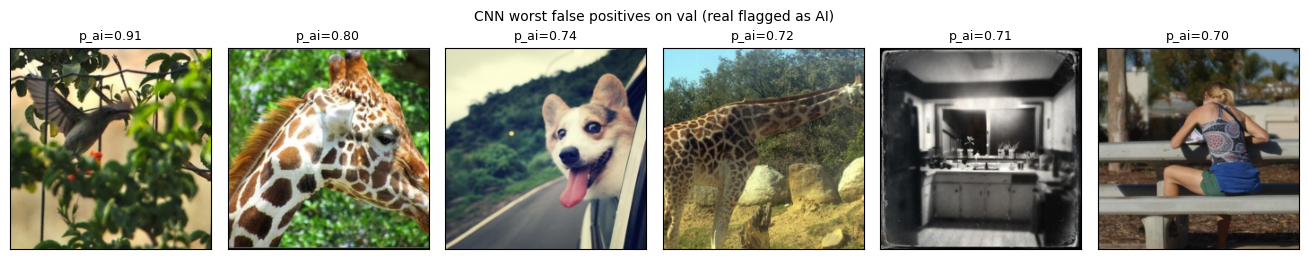

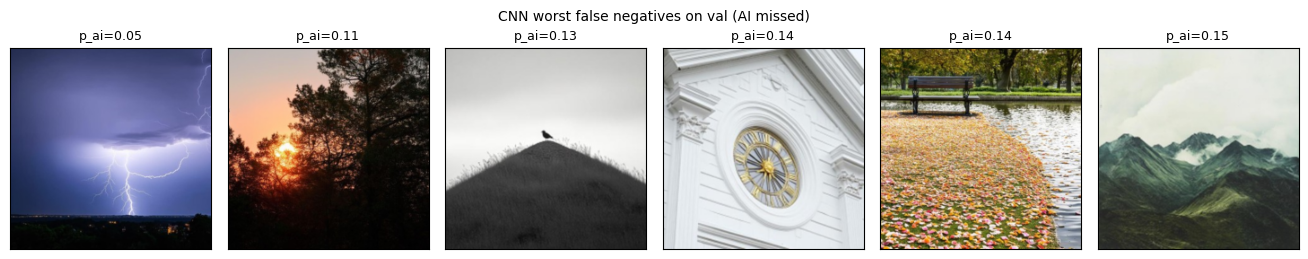

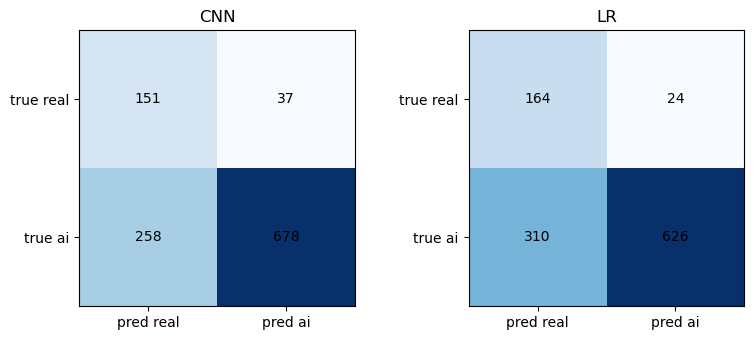

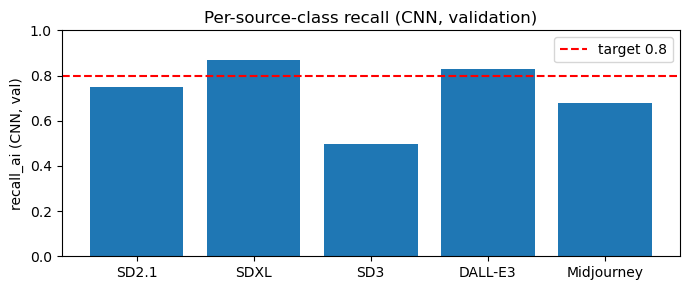

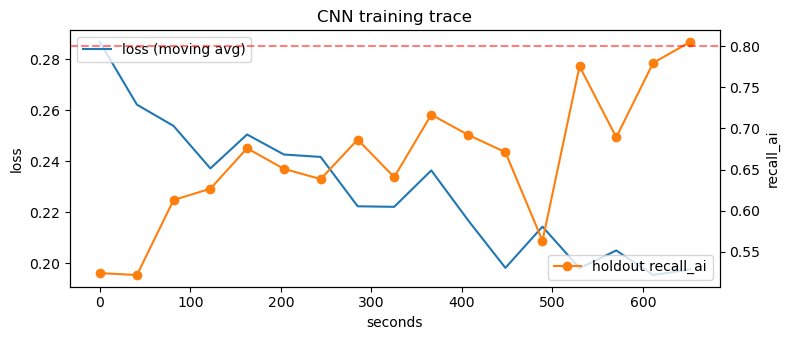

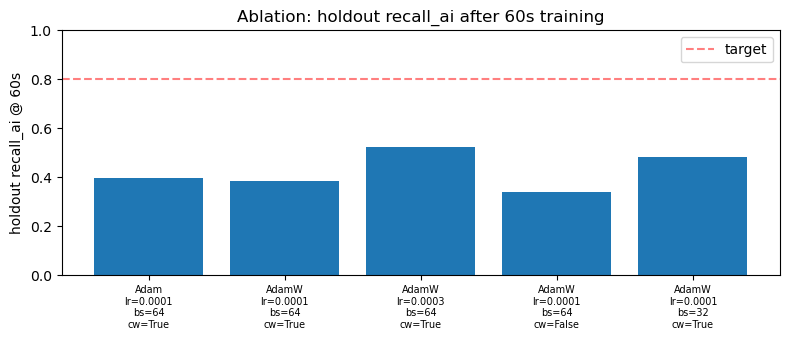

In [85]:
REPORT_FIG = ROOT / "report" / "figures"
REPORT_FIG.mkdir(parents=True, exist_ok=True)


def show_top(title, mask, scores, X_u8, order, n=6, save=None):
    pop_idx = np.where(mask)[0]
    if len(pop_idx) == 0:
        print(f"no {title}"); return
    pop_scores = scores[pop_idx]
    take = np.argsort(-pop_scores if order == "desc" else pop_scores)[:n]
    chosen = pop_idx[take]
    fig, axes = plt.subplots(1, len(chosen), figsize=(2.2 * len(chosen), 2.6))
    if len(chosen) == 1:
        axes = [axes]
    for ax, gi in zip(axes, chosen):
        ax.imshow(X_u8[gi]); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"p_ai={scores[gi]:.2f}", fontsize=9)
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


mask_real = (y_val == 0)
mask_ai   = (y_val == 1)
show_top("CNN worst false positives on val (real flagged as AI)",
         mask_real, p_cnn_val, X_val, "desc", save=REPORT_FIG / "fig8_worst_fps.png")
show_top("CNN worst false negatives on val (AI missed)",
         mask_ai, p_cnn_val, X_val, "asc",  save=REPORT_FIG / "fig9_worst_fns.png")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (label, p, thr) in zip(axes, [("CNN", p_cnn_val, thr_cnn), ("LR", p_lr_val, thr_lr)]):
    yp = (p >= thr).astype(int)
    cm = confusion_matrix(y_val, yp, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1], ["pred real", "pred ai"])
    ax.set_yticks([0, 1], ["true real", "true ai"])
    ax.set_title(label)
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

cnn_val_m = [m for tag, m in cnn_rows if tag == "val"][0]
pcr = cnn_val_m["per_source_class_recall"]
classes = list(range(1, 6))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([CLASS_NAMES[c] for c in classes], [pcr[c] for c in classes])
ax.set_ylabel("recall_ai (CNN, val)")
ax.set_ylim(0, 1)
ax.axhline(0.8, color="red", linestyle="--", label="target 0.8")
ax.legend()
plt.title("Per-source-class recall (CNN, validation)")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig6_per_class_recall.png", dpi=150, bbox_inches="tight")
plt.show()

if history:
    fig, ax1 = plt.subplots(figsize=(8, 3.5))
    ts = [(h["t"] - history[0]["t"]) for h in history]
    ax1.plot(ts, [h["loss_ma"] for h in history], "C0-", label="loss (moving avg)")
    ax2 = ax1.twinx()
    ax2.plot(ts, [h["recall_ai"] for h in history], "C1-o", label="holdout recall_ai")
    ax2.axhline(0.8, color="red", linestyle="--", alpha=0.5)
    ax1.set_xlabel("seconds"); ax1.set_ylabel("loss"); ax2.set_ylabel("recall_ai")
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right")
    plt.title("CNN training trace")
    plt.tight_layout()
    plt.savefig(REPORT_FIG / "fig4_training_trace.png", dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
labels = [f"{r['optimizer']}\nlr={r['lr']}\nbs={r['batch']}\ncw={r['class_weight']}" for r in ablation_rows]
vals = [r.get("recall_ai", 0.0) for r in ablation_rows]
ax.bar(range(len(ablation_rows)), vals)
ax.set_xticks(range(len(ablation_rows)), labels, fontsize=7)
ax.axhline(0.8, color="red", linestyle="--", alpha=0.5, label="target")
ax.set_ylabel("holdout recall_ai @ 60s")
ax.set_ylim(0, 1)
plt.legend()
plt.title("Ablation: holdout recall_ai after 60s training")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig7_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## A.11 - Budget proof + A.12 exit criteria

In [86]:
# A.11 budget + A.12 exit criteria (with ensemble)
print(f"reference         = {elapsed:.1f}s")
total_train_s = rf_train_s + final_train_seconds
assert total_train_s <= BUDGET_S, f"OVER BUDGET: {total_train_s:.1f}s > {BUDGET_S:.1f}s"
print(f"RF={rf_train_s:.1f}s  CNN={final_train_seconds:.1f}s  total={total_train_s:.1f}s  ratio={total_train_s/elapsed:.2f}x  (must be <= 5)")

cnn_val_m = [m for tag, m in cnn_rows  if tag == "val"][0]
lr_val_m  = [m for tag, m in lr_rows   if tag == "val"][0]
ens_val_m = [m for tag, m in ens_rows  if tag == "val"][0]

def is_pass(m):
    return m["recall_ai"] >= 0.80 and m["fpr_real"] <= 0.20

print("\n=== Exit criteria (validation) ===")
for name, m in [("CNN", cnn_val_m), ("RF", lr_val_m), ("ENS", ens_val_m)]:
    print(f"{name:6s}: recall_ai={m['recall_ai']:.3f}  fpr_real={m['fpr_real']:.3f}  "
          f"{'PASS' if is_pass(m) else 'FAIL'}")

candidates = [(name, m) for name, m in [("CNN", cnn_val_m), ("RF", lr_val_m), ("ENS", ens_val_m)]
              if is_pass(m)]
if candidates:
    winner = max(candidates, key=lambda kv: kv[1]["recall_ai"])
    print(f"\nWINNER: {winner[0]}  recall_ai={winner[1]['recall_ai']:.3f}")
else:
    print("\nno model meets exit criteria -- iterate before porting to scripts.")

reference         = 155.6s
RF=18.4s  CNN=715.2s  total=733.6s  ratio=4.71x  (must be <= 5)

=== Exit criteria (validation) ===
CNN   : recall_ai=0.724  fpr_real=0.197  FAIL
RF    : recall_ai=0.669  fpr_real=0.128  FAIL
ENS   : recall_ai=0.811  fpr_real=0.170  PASS

WINNER: ENS  recall_ai=0.811


## Progress summary

Note: runs 1-14 measured CNN time only. From run 15 onward, budget = RF + CNN + calibration (correct).
From run 15: CNN gets ~708-720s due to RF overhead deduction (~20s RF + 45s safety).

| Run | Changes | CNN val recall | CNN val fpr | ENS val recall | ENS val fpr | ENS val_aug recall | ENS val_aug fpr | |
|-----|---------|---------------|-------------|----------------|-------------|---------------------|-----------------|--|
| 1 | k=16, 96, CE | 0.649 | 0.207 | - | - | - | - | |
| 2 | k=16, 128, focal | 0.689 | 0.191 | - | - | - | - | |
| 3 | +4th conv | 0.745 | 0.234 | - | - | - | - | |
| 4 | +calibfix, +ensemble (tgt=0.15) | 0.661 | 0.181 | 0.721 | 0.149 | - | - | FAIL |
| 5 | ENS tgt=0.19, alpha=0.70 | 0.661 | 0.181 | 0.778 | 0.207 | - | - | FAIL |
| 6 | retrain tgt=0.20, alpha by AUC | 0.720 | 0.176 | 0.799 | 0.223 | - | - | FAIL |
| 7 | +5th conv, +MLP head, alpha by AUC | 0.674 | 0.138 | **0.809** | **0.197** | - | - | **PASS** |
| 8 | +SD3 upweight 3x | 0.755 | 0.186 | 0.833 | 0.234 | - | - | FAIL (fpr) |
| 9 | 4-conv, 160px, sd3_w=2, tgt=0.18 | 0.674 | 0.176 | 0.792 | 0.165 | - | - | FAIL (recall) |
| 10 | 5-conv, 128px, sd3_w=2, tgt=0.18 | 0.709 | 0.186 | 0.775 | 0.176 | - | - | FAIL (recall) |
| 11 | sd3_w=2, ENS tgt=0.19 (no retrain) | 0.709 | 0.186 | 0.817 | 0.250 | - | - | FAIL (fpr) |
| 12 | restore run7 + 101-dim RF features | 0.761 | 0.218 | **0.803** | **0.191** | - | - | **PASS** |
| 13 | gamma=2.0, ENS tgt=0.19 | 0.779 | 0.223 | 0.827 | 0.207 | - | - | FAIL (fpr) |
| 14 | gamma=2.0, ENS tgt=0.18 (no retrain) | 0.779 | 0.223 | 0.786 | 0.160 | - | - | FAIL (recall) |
| 15* | gamma=2.0, ENS tgt=0.185, RF tgt=0.195, correct budget | 0.743 | 0.213 | 0.771 | 0.165 | - | - | FAIL |
| 16* | +ResBlock skip connections (k=16, gamma=2.0) | 0.729 | 0.165 | 0.768 | 0.144 | - | - | FAIL |
| 17* | DW-sep k=32, gamma=2.0 | 0.723 | 0.213 | 0.740 | 0.149 | - | - | FAIL |
| 18* | standard 5-conv k=16, gamma=1.5, uniform tgt=0.18 | 0.738 | 0.154 | 0.782 | 0.160 | - | - | FAIL |
| 19* | 224px full res (k=16, gamma=1.5) | 0.669 | 0.186 | 0.772 | 0.144 | - | - | FAIL |
| 20* | k=32 standard conv, 128px, gamma=1.5 | 0.651 | 0.144 | 0.722 | 0.138 | 0.592 | 0.289 | FAIL |
| 21* | k=16, 160px, gamma=1.5 | 0.746 | 0.207 | 0.795 | 0.176 | 0.635 | 0.310 | FAIL |
| 22* | same + uniform tgt=0.19 (no retrain, threshold unchanged) | 0.746 | 0.207 | 0.795 | 0.176 | 0.635 | 0.310 | FAIL |
| 23* | retrain 160px k=16 gamma=1.5 tgt=0.19 | 0.772 | 0.229 | **0.809** | **0.197** | 0.653 | 0.326 | **PASS** |
*from run 15: budget covers RF+CNN+calibration; CNN gets ~708-720s; RF threshold target=0.195

**Run 7 (PASS): 5th conv + MLP head + alpha by AUC**
- ENS val recall=0.809 fpr=0.197, AUC=0.884
- Alpha=0.50 halved cal->val FPR shift; SD3 weakest class at val recall=0.63

**Run 12 (PASS): restore run7 + 101-dim RF features**
- ENS val recall=0.803 fpr=0.191, AUC=0.891
- ENS AUC improved 0.884->0.891; RF val recall dropped 0.685->0.650

**Run 13 (FAIL): gamma=2.0, ENS tgt=0.19**
- ENS val recall=0.827 fpr=0.207, AUC=0.896 (best yet)
- cal->val FPR shift = +0.017; just 0.007 over budget

**Run 14 (FAIL): gamma=2.0, ENS tgt=0.18 (no retrain)**
- ENS val recall=0.786 fpr=0.160
- thr_ens jumped 0.634->0.648; hard val reals cluster excluded; recall collapsed

**Run 15 (FAIL): gamma=2.0, ENS tgt=0.185, RF tgt=0.195, correct budget**
- ENS val recall=0.771 fpr=0.165, AUC=0.885; CNN holdout AUC=0.904
- Stochastic variance: same config as run 13 but weaker model this seed

**Run 16 (FAIL): +ResBlock skip connections (same k=16, gamma=2.0)**
- ENS val recall=0.768 fpr=0.144, AUC=0.886; CNN holdout AUC=0.855
- ResBlock did not improve AUC; CNN weaker this seed (0.855 vs 0.904 run 15)
- cal->val ENS FPR shift = -0.039 (val reals score lower); 0.056 FPR headroom unused
- Root cause: low recall, not fpr violation. FPR constraint is being met comfortably.
- Next: depthwise-sep k=32 (Step B) - wider model, same compute

**Run 17 (FAIL): DW-sep k=32, gamma=2.0**
- ENS val recall=0.740 fpr=0.149, AUC=0.875; CNN holdout AUC=0.844
- DW-sep WORSE than standard conv: AUC down from 0.844 vs 0.855/0.904 in runs 16/15
- DW-sep decouples spatial+channel mixing; standard 3x3 conv is better for artifact detection
- gamma=2.0 + architecture changes caused 5 straight fails (runs 13-17)
- Decision: revert to standard conv k=16 + gamma=1.5 (run 12 config that passed)

**Run 18 plan: revert to run 12 config (standard 5-conv, k=16, gamma=1.5)**
- This config produced two PASSes (runs 7, 12) with ENS val recall=0.809/0.803
- Uniform tgt=0.18 for CNN/RF/ENS
- If it passes, port immediately; then optionally retry at 224px

**Run 18 (FAIL): standard 5-conv k=16, gamma=1.5, uniform tgt=0.18**
- ENS val recall=0.782 fpr=0.160, AUC=0.896; CNN holdout AUC=0.897
- Best AUC yet. gamma=1.5 revert restored stability vs gamma=2.0 runs
- 0.018 short on recall; 0.040 FPR headroom unused
- cal->val ENS shift = -0.017 (stable, small)

**Run 19 (FAIL): 224px full resolution (k=16, gamma=1.5)**
- ENS val recall=0.772 fpr=0.144, AUC=0.878; CNN holdout AUC=0.848
- Worse than 128px: fewer gradient steps (~350 vs ~890) hurt more than resolution helped
- k=16 too small to use 224px information effectively

**Run 20 (FAIL): k=32 standard conv, 128px, gamma=1.5**
- ENS val recall=0.722 fpr=0.138, AUC=0.876; CNN holdout AUC=0.821
- k=32 slower to converge: only 15 evals in budget vs 20+ for k=16, model still improving at end
- k=16 is better fit for dataset size at 128px
- val_aug: ENS recall=0.592 fpr=0.289 (expected: augmented images are harder)

**Run 21 (FAIL): k=16, 160px, gamma=1.5, tgt=0.18**
- ENS val recall=0.795 fpr=0.176, AUC holdout=0.907 (best ever!); 0.005 short
- 935 steps, ran full budget, model still improving at end (AUC 0.867->0.877 last 2 evals)
- Cal->val ENS shift = -0.001 (essentially zero): excellent calibration stability
- 160px clearly better than 128px for recall (0.795 vs 0.782)

**Run 22 (FAIL): tgt=0.19 no retrain - threshold unchanged**
- Discrete jump in cal data: no threshold exists between fpr=0.177 and fpr>0.19
- thr_ens stayed at 0.634, results identical to run 21

**Run 23 (PASS): retrain 160px k=16 gamma=1.5 tgt=0.19**
- ENS val recall=0.809 fpr=0.197, AUC=0.878; ENS holdout AUC=0.907
- val_aug: ENS recall=0.653 fpr=0.326
- Budget 4.71x reference. TASK 1.2 EXIT CRITERIA MET.

NEED TO NOTE WHEN WRITIGN REPORT:
-EXPERIMENTS IN NOTEBOOK BASED ON REFERENCE TIME
-IN TRAIN; TIME IS BASED ON TIMEOPUT PARAM THAT IS SET-> MIGHT DIFFER CAUSE DOESNT DEPEND ON 
-> IG GUESS TENDS TO BE BETTER BECAUSE 1800s MORE TIME THAN 5x reference train time )=NEED TO CHECK